In [1]:
from util import *

directory = r'../../data/llm_evaluation/fiscal/'

%matplotlib notebook

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# resume work
df_test_stance_e = pd.read_excel(directory+'df_test_stance_fis_4_v1.xlsx')
df_test_stance_a = pd.read_excel(directory+'df_test_stance_fis_0_v1.xlsx')
df_test_stance_b = pd.read_excel(directory+'df_test_stance_fis_1_v1.xlsx')
df_test_stance_c = pd.read_excel(directory+'df_test_stance_fis_2_v1.xlsx')
df_test_stance_d = pd.read_excel(directory+'df_test_stance_fis_3_v1.xlsx')
df_test_stance_a = pd.concat([df_test_stance_e, df_test_stance_a, df_test_stance_b, df_test_stance_c, df_test_stance_d], ignore_index=True)
df_test_stance_b = pd.read_excel(directory+'df_train_stance_gpt.xlsx').drop(['Print ISBN', 'country', 'year', 'text', 'stance_near_term'], axis=1)
df_test_stance = df_test_stance_a.merge(df_test_stance_b)

df_test_agree_e = pd.read_excel(directory+'df_test_agree_fis_4.xlsx')
df_test_agree_a = pd.read_excel(directory+'df_test_agree_fis_0.xlsx')
df_test_agree_b = pd.read_excel(directory+'df_test_agree_fis_1.xlsx')
df_test_agree_c = pd.read_excel(directory+'df_test_agree_fis_2.xlsx')
df_test_agree_d = pd.read_excel(directory+'df_test_agree_fis_3.xlsx')
df_test_agree_a = pd.concat([df_test_agree_a, df_test_agree_b, df_test_agree_c, df_test_agree_d, df_test_agree_e], ignore_index=True)
df_test_agree_b = pd.read_excel(directory+'df_train_agree_gpt.xlsx').drop(['Print ISBN', 'country', 'year', 'staff', 'buff', 'agreement_general', 'disagreement_areas'], axis=1)
df_test_agree = df_test_agree_a.merge(df_test_agree_b)

In [ ]:
df_test_agree.drop(['disagreement_areas_government debt & financing',
       'disagreement_areas_government debt & financing_gpt_ft',
       'disagreement_areas_government revenue',
       'disagreement_areas_government revenue_gpt_ft',
       'disagreement_areas_near-term policy direction',
       'disagreement_areas_near-term policy direction_gpt_ft',
       'disagreement_areas_government expenditure',
       'disagreement_areas_government expenditure_gpt_ft',
       'disagreement_areas_economic fundamentals',
       'disagreement_areas_economic fundamentals_gpt_ft',
       'disagreement_areas_fiscal framework',
       'disagreement_areas_fiscal framework_gpt_ft',
       'disagreement_areas_public sector borrowing',
       'disagreement_areas_public sector borrowing_gpt_ft',
       'disagreement_areas_medium-term fiscal stance',
       'disagreement_areas_medium-term fiscal stance_gpt_ft',
       'disagreement_areas_fiscal multiplier estimation',
       'disagreement_areas_fiscal multiplier estimation_gpt_ft',
       'disagreement_areas_political cycle',
       'disagreement_areas_political cycle_gpt_ft'], axis=1, inplace=True)

In [ ]:
df_test_agree['disagreement_areas_gpt_ft'].value_counts()

,count
disagreement_areas_gpt_ft,
[],207
['government debt & financing'],26
['near-term policy direction'],24
['government revenue'],16
['government expenditure'],8
['economic fundamentals'],6
['fiscal framework'],5
near-term policy direction,2
"['economic fundamentals', 'near-term policy direction']",2


In [ ]:
model_l = ['gpt1', 'gpt2', 'gpt5', 'gpt6', 'gpt3', 'gpt4', 'gpt_ft']
key_columns = ['stance_near_term']
key_columns_agree = ['agreement', 'agreement_general', 'disagreement_areas', 'disagreement_areas_general']

for i, row in df_test_agree.iterrows():
    for ty in ['staff', 'buff']:
        for col in key_columns:
            df_test_agree.loc[i, ty+'_'+col] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][col]
            for model in model_l:
                var = col + '_' + model
                df_test_agree.loc[i, ty+'_'+var] = df_test_stance[(df_test_stance['Print ISBN']==row['Print ISBN'])&(df_test_stance['type']==ty)].iloc[0][var]

# agreement general
df_test_agree['agreement'] = df_test_agree['agreement_general']
df_test_agree['agreement_stance_near_term'] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_near_term'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_near_term']!=x['staff_stance_near_term'] or x['buff_stance_near_term'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_near_term']!=x['buff_stance_near_term'] else 'mostly agree' if x['staff_stance_near_term']==x['buff_stance_near_term'] else 'disagreement exists', axis=1)
df_test_agree['disagreement_areas_general'] = df_test_agree['disagreement_areas']

for model in model_l:
    df_test_agree['agreement_stance_near_term'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['staff_stance_near_term'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['staff_stance_near_term'+'_'+model]!=x['staff_stance_near_term'+'_'+model] or x['buff_stance_near_term'+'_'+model] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['buff_stance_near_term'+'_'+model]!=x['buff_stance_near_term'+'_'+model] else 'mostly agree' if x['staff_stance_near_term'+'_'+model]==x['buff_stance_near_term'+'_'+model] else 'disagreement exists', axis=1)
    df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree['disagreement_areas'+'_'+model].fillna('')
    df_test_agree['disagreement_areas_general'+'_'+model] = df_test_agree.apply(lambda x: (x['disagreement_areas_general'+'_'+model]+'; near-term policy direction').strip('; ') if x['agreement_stance_near_term'+'_'+model]=='disagreement exists' else x['disagreement_areas_general'+'_'+model], axis=1)
    df_test_agree['agreement_general'+'_'+model] = df_test_agree.apply(lambda x: 'irrelevant' if x['agreement_stance_near_term'+'_'+model]=='irrelevant' and (x['agreement'+'_'+model] in ['', 'n', 'nan', 'irrelevant'] or x['agreement'+'_'+model]!=x['agreement'+'_'+model]) else 'disagreement exists' if x['agreement_stance_near_term'+'_'+model]=='disagreement exists' or x['agreement'+'_'+model]=='disagreement exists' else 'mostly agree', axis=1)

# disagreement areas dummy
for c in df_test_agree.columns:
    if 'disagreement_areas' in c:
        df_test_agree[c] = df_test_agree[c].apply(lambda x: x.replace('Future Policy Stance', 'Future Policy Direction') if x==x else x)

da_vals = list(set(itertools.chain.from_iterable(df_test_agree['disagreement_areas'].apply(lambda x: x.split('; ') if x==x else []))))

for model in model_l:
    for val in da_vals:
        for col in ['disagreement_areas', 'disagreement_areas_general']:
            df_test_agree[col+'_'+val] = df_test_agree[col].apply(lambda x: x==x and val in x)
            df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)

<ipython-input-107-83f2029259c5>:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)
<ipython-input-107-83f2029259c5>:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree[col+'_'+val+'_'+model] = df_test_agree[col+'_'+model].apply(lambda x: x==x and val in x)
<ipython-input-107-83f2029259c5>:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [ ]:
for model in model_l:
    for col in key_columns:
        print(df_test_stance[col+'_'+model].isna().value_counts())

stance_near_term_gpt1
False    600
Name: count, dtype: int64
stance_near_term_gpt2
False    600
Name: count, dtype: int64
stance_near_term_gpt5
False    600
Name: count, dtype: int64
stance_near_term_gpt6
False    600
Name: count, dtype: int64
stance_near_term_gpt3
False    600
Name: count, dtype: int64
stance_near_term_gpt4
False    600
Name: count, dtype: int64
stance_near_term_gpt_ft
False    600
Name: count, dtype: int64


In [ ]:
for model in model_l:
    for col in ['agreement']:
        print(df_test_agree[col+'_'+model].isna().value_counts())

agreement_gpt1
False    300
Name: count, dtype: int64
agreement_gpt2
False    300
Name: count, dtype: int64
agreement_gpt5
False    300
Name: count, dtype: int64
agreement_gpt6
False    300
Name: count, dtype: int64
agreement_gpt3
False    300
Name: count, dtype: int64
agreement_gpt4
False    300
Name: count, dtype: int64
agreement_gpt_ft
False    300
Name: count, dtype: int64


In [ ]:
results_l = []
for col in key_columns:
    for model in model_l:
        results_l.append(evaluate(df_test_stance, model, col, stance=True))
for col in key_columns_agree:
    for model in model_l:
        results_l.append(evaluate(df_test_agree, model, col))

df_result = pd.DataFrame(results_l)
df_result['name'] = df_result['name'].apply(lambda x: x.replace('gpt1', 'gpt-4o').replace('gpt2', 'gpt-4o_long_prompt').replace('gpt3', 'gpt-4o_cot').replace('gpt4','gpt-4o_few_shot').replace('gpt5','gpt-4o-mini').replace('gpt6','gpt-3.5-turbo').replace('gpt_ft','gpt-4o-mini_finetuned').replace('mistral7b','mistral-7b-instruct').replace('phi', 'phi-3-small-128k-instruct').replace('gemma', 'gemma-2-9b-it'))


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1760: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1760: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1760: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/usr/local/lib/python3.10/dist-

In [ ]:
df_result.to_excel(directory+'df_result_fiscal.xlsx', index=False)

In [ ]:
group1 = ['gpt-4o', 'gpt-4o_long_prompt', 'gpt-4o_cot']
group2 = ['gpt-4o_long_prompt', 'gpt-4o-mini', 'gpt-4o_few_shot', 'gpt-4o-mini_finetuned']
group3 = ['gpt-4o_long_prompt',
 'gpt-4o-mini',
 'gpt-3.5-turbo', 'gemma-2-9b-it',
 'llama3-8b-instruct',
 'mistral-7b-instruct',
 'phi-3-small-128k-instruct']

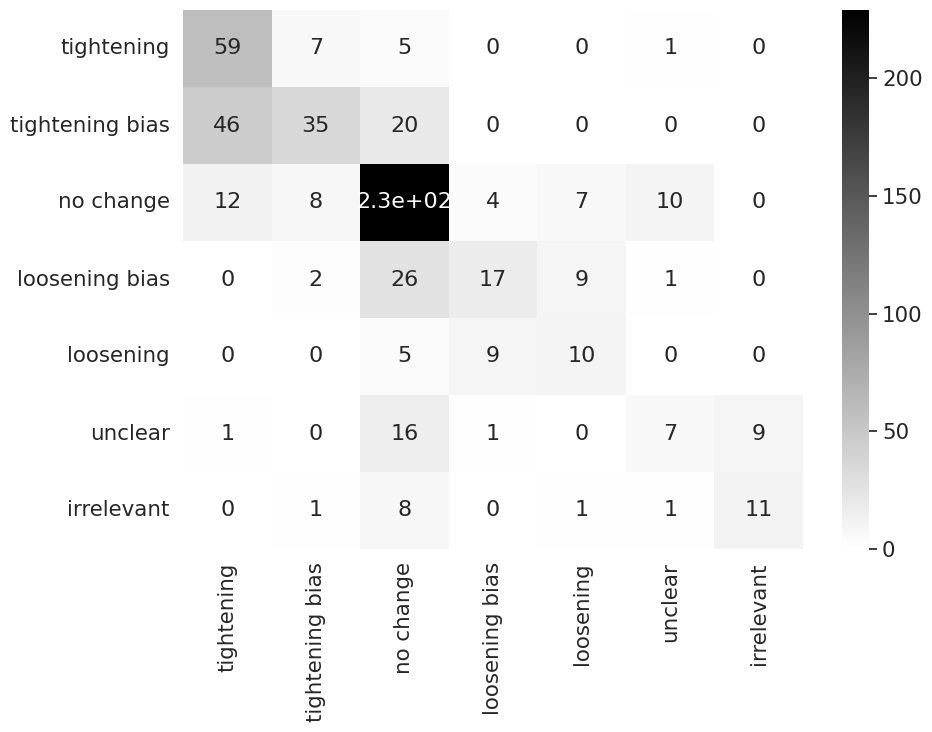

In [ ]:
labels = ['tightening', 'tightening bias', 'no change', 'loosening bias', 'loosening', 'unclear', 'irrelevant']
cm = confusion_matrix(df_test_stance['stance_future'], df_test_stance['stance_future_gpt5'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.show()

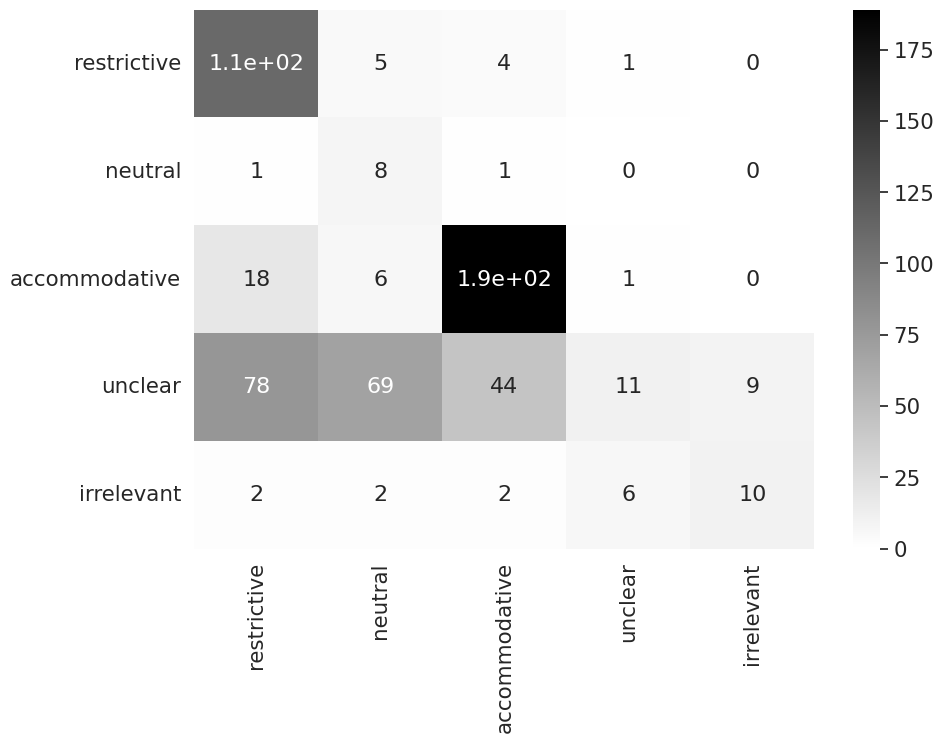

In [ ]:
labels = ['restrictive', 'neutral', 'accommodative', 'unclear', 'irrelevant']
cm = confusion_matrix(df_test_stance['stance_current'], df_test_stance['stance_current_gpt5'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.show()

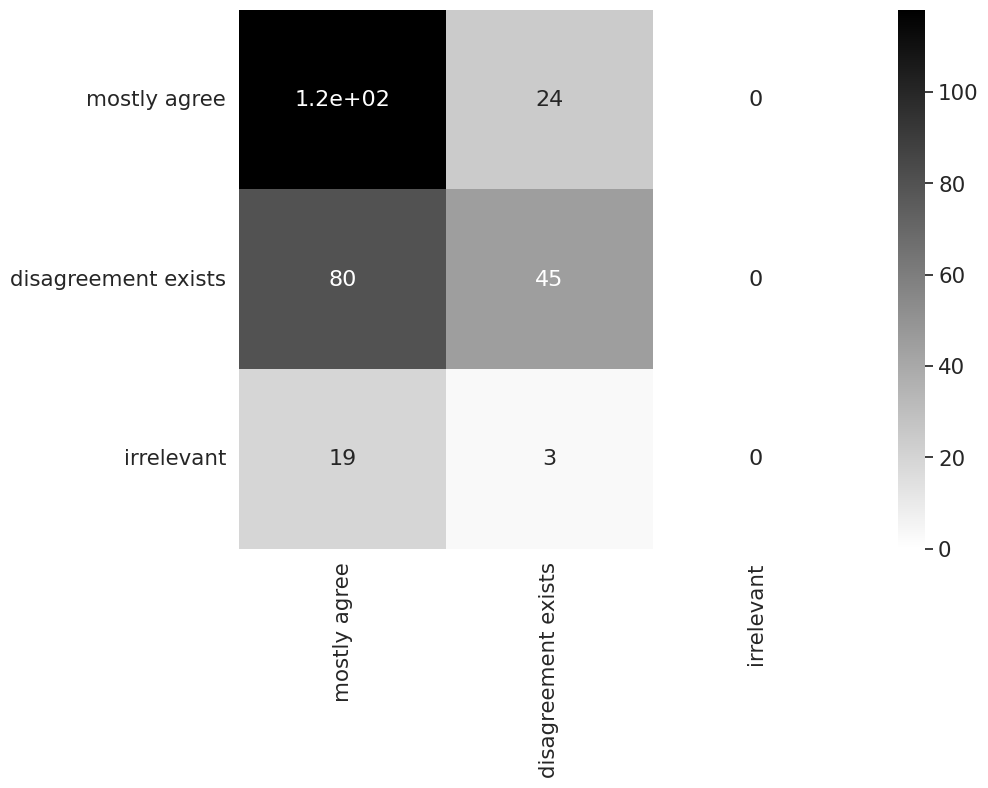

In [ ]:
labels = ['mostly agree', 'disagreement exists', 'irrelevant']
cm = confusion_matrix(df_test_agree['agreement'], df_test_agree['agreement_gpt5'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xticks([0.5,1.5,2.5], labels, rotation='vertical')
plt.yticks([0.5,1.5,2.5], labels, rotation='horizontal')
plt.show()

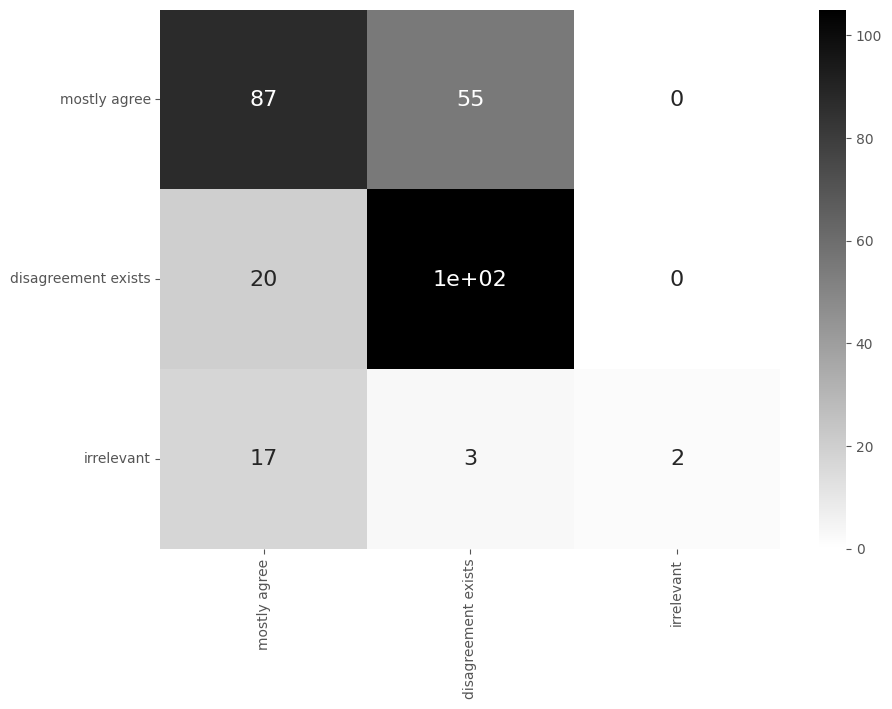

In [ ]:
labels = ['mostly agree', 'disagreement exists', 'irrelevant']
cm = confusion_matrix(df_test_agree['agreement_general'], df_test_agree['agreement_general_gpt1'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xticks([0.5,1.5,2.5], labels, rotation='vertical')
plt.yticks([0.5,1.5,2.5], labels, rotation='horizontal')
plt.show()

In [ ]:
df_test_agree[(df_test_agree['agreement_stance_future']=='mostly agree')&(df_test_agree['agreement_stance_future_gpt_ft']=='disagreement exists')][['staff_stance_future', 'buff_stance_future', 'staff_stance_future_gpt_ft', 'buff_stance_future_gpt_ft']].value_counts().sort_index()

staff_stance_future  buff_stance_future  staff_stance_future_gpt_ft  buff_stance_future_gpt_ft
loosening            loosening           loosening                   no change                    1
                                         loosening bias              loosening                    1
                                         no change                   loosening bias               1
loosening bias       loosening bias      loosening                   no change                    1
                                         loosening bias              loosening                    1
                                                                     no change                    2
                                                                     tightening bias              1
                                         no change                   loosening bias               1
no change            no change           loosening bias              loosening                    1
                                                                     no change                    4
                                         no change                   loosen                       1
                                                                     loosening                    1
                                                                     loosening bias               5
                                                                     tightening bias              2
                                         tightening                  no change                    2
                                         tightening bias             no change                    2
tightening           tightening          tightening                  no change                    1
                                                                     tightening bias              6
tightening bias      tightening bias     no change                   tightening                   1
                                                                     tightening bias              1
                                         tightening                  no change                    1
                                                                     tightening bias              2
                                         tightening bias             no change                    7
                                                                     tightening                   3
Name: count, dtype: int64

In [ ]:
df_temp = df_result[(df_result['variable']=='stance_near_term')&(df_result['name'].apply(lambda x: x in group1))].drop(['accuracy', 'f1_score','recall', 'f1_score_e'], axis=1)
df_temp

,name,variable,accuracy_m,f1_score_m
0,gpt-4o,stance_near_term,0.386667,0.445923
1,gpt-4o_long_prompt,stance_near_term,0.568333,0.608329
4,gpt-4o_cot,stance_near_term,0.636667,0.646100


Text(0.5, 0, '')

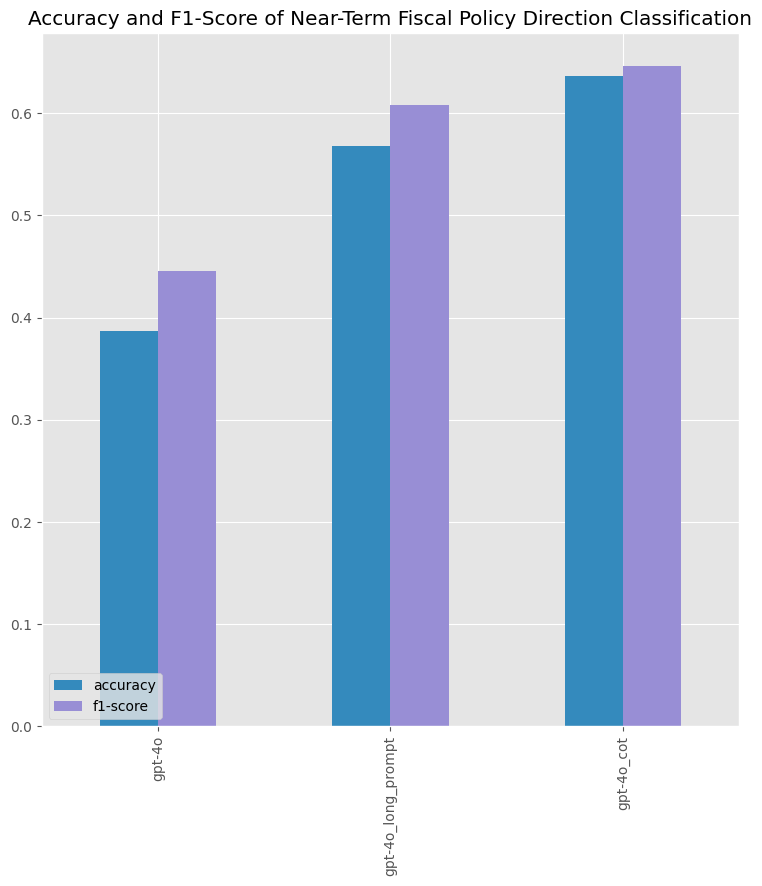

In [ ]:
df_temp.set_index('name')[['accuracy_m', 'f1_score_m']].plot.bar(color=colors[1:])
plt.title('Accuracy and F1-Score of Near-Term Fiscal Policy Direction Classification')
plt.legend(['accuracy', 'f1-score'], loc='lower left')
plt.xlabel('')

In [ ]:
df_temp = df_result[(df_result['variable']=='agreement')&(df_result['name'].apply(lambda x: x in group1))].drop(['accuracy', 'f1_score', 'f1_score_e'], axis=1)
df_temp

,name,variable,accuracy_m,f1_score_m,recall
7,gpt-4o,agreement,0.773333,0.775824,0.71
8,gpt-4o_long_prompt,agreement,0.753333,0.758054,0.73
11,gpt-4o_cot,agreement,0.796667,0.800119,0.78


Text(0.5, 0, '')

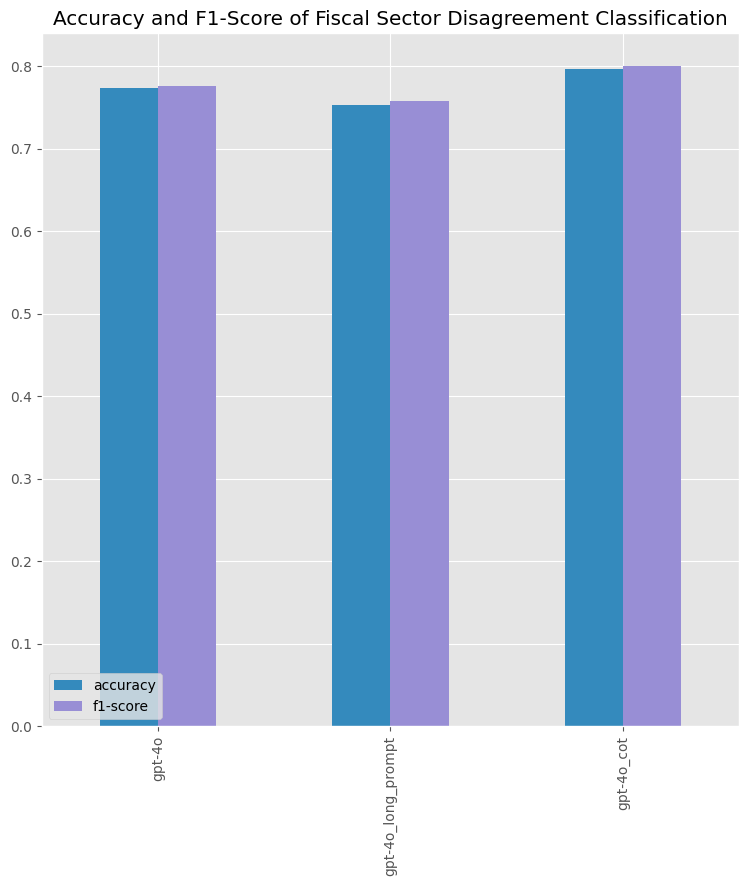

In [ ]:
df_temp.set_index('name')[['accuracy_m','f1_score_m']].plot.bar(color=colors[1:])
# df_temp.set_index('name')[].plot.bar(color=colors[2])
plt.title('Accuracy and F1-Score of Fiscal Sector Disagreement Classification')
plt.legend(['accuracy', 'f1-score'], loc='lower left')
plt.xlabel('')

In [ ]:
df_result[(df_result['variable']=='disagreement_areas_general')&(df_result['name'].apply(lambda x: x in group2))].drop(['accuracy_m', 'f1_score_m', 'f1_score_e'], axis=1)

,name,variable,accuracy,f1_score,recall
55,gpt-4o,disagreement_areas_general,0.532872,0.584924,0.737931
56,gpt-4o-mini,disagreement_areas_general,0.536332,0.529791,0.696552
64,gpt-4o_few_shot,disagreement_areas_general,0.581315,0.571213,0.710345
65,gpt-4o-mini_finetuned,disagreement_areas_general,0.619377,0.528459,0.655172


In [ ]:
df_result[(df_result['variable']=='agreement_general')].drop('f1_score_e', axis=1)

,name,variable,accuracy,f1_score,accuracy_m,f1_score_m,recall
33,gpt-4o,agreement_general,0.671280,0.649480,0.730104,0.730227,0.840
34,gpt-4o-mini,agreement_general,0.653979,0.625162,0.716263,0.716630,0.816
35,gpt-3.5-turbo,agreement_general,0.584775,0.561444,0.643599,0.644334,0.608
36,gemma-2-9b-it,agreement_general,0.470588,0.423888,0.512111,0.479821,0.816
37,llama3-8b-instruct,agreement_general,0.560554,0.537140,0.595156,0.595156,0.688
38,mistral-7b-instruct,agreement_general,0.591696,0.567578,0.650519,0.650348,0.592
39,phi-3-small-128k-instruct,agreement_general,0.501730,0.477996,0.536332,0.533932,0.656
40,gpt-4o_long_prompt,agreement_general,0.657439,0.640299,0.698962,0.698666,0.816
41,gpt-4o_cot,agreement_general,0.657439,0.637188,0.709343,0.709718,0.808
42,gpt-4o_few_shot,agreement_general,0.678201,0.665649,0.723183,0.723309,0.832


In [ ]:
df_result[(df_result['variable']=='disagreement_areas_general')].drop(['accuracy_m', 'f1_score_m', 'f1_score_e'], axis=1)

,name,variable,accuracy,f1_score,recall
55,gpt-4o,disagreement_areas_general,0.532872,0.584924,0.737931
56,gpt-4o-mini,disagreement_areas_general,0.536332,0.529791,0.696552
57,gpt-3.5-turbo,disagreement_areas_general,0.515571,0.444888,0.496552
58,gemma-2-9b-it,disagreement_areas_general,0.311419,0.418638,0.600000
59,llama3-8b-instruct,disagreement_areas_general,0.391003,0.418517,0.537931
60,mistral-7b-instruct,disagreement_areas_general,0.446367,0.424230,0.503448
61,phi-3-small-128k-instruct,disagreement_areas_general,0.470588,0.382549,0.503448
62,gpt-4o_long_prompt,disagreement_areas_general,0.522491,0.562466,0.717241
63,gpt-4o_cot,disagreement_areas_general,0.529412,0.558203,0.703448
64,gpt-4o_few_shot,disagreement_areas_general,0.581315,0.571213,0.710345


In [ ]:
# df_test_stance[df_test_stance['type']=='buff']['stance_current'].value_counts().sort_index().plot.pie()
# plt.title('current stance - authorities')
# plt.ylabel('')

pd.DataFrame([i for i in '; '.join(df_test_agree['disagreement_areas'].fillna('')).split('; ') if i != ''])[0].value_counts().plot.pie()
plt.title('disagreement_areas')
plt.ylabel('')

In [ ]:
df_test_agree['text_len'] = df_test_agree['staff'].apply(lambda x: len(x))+df_test_agree['buff'].apply(lambda x: len(x))

<ipython-input-104-7f2d89efc12f>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_agree['text_len'] = df_test_agree['staff'].apply(lambda x: len(x))+df_test_agree['buff'].apply(lambda x: len(x))
